In [5]:
# ENSO QUICK-LOOK REPLACEMENT FOR MY ncl SCRIPT


In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import pywt
from scipy.fft import fft, fftfreq
from scipy.signal import correlate
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.colors as mcolors



from datetime import datetime, timedelta

import enso_quick_look_utils as enso_ql

import importlib

In [2]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [3]:
cluster = NCARCluster(project='P93300642',interface='ext',walltime="12:00:00")
cluster
cluster.scale(jobs=32)
client = Client(cluster)
client

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/apps/opt/con

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.173:35373,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B



** 1. Grabbing Case Data **
  - Using all of the available data
  - Reading  732  files (first/last)
   - /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316/atm/hist/b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316.cam.h0a.0001-01.nc
   - /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316/atm/hist/b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316.cam.h0a.0061-12.nc
  - Opening detected h0a output files...
  -Done
  - Write out files of 2D field TS
     /glade/derecho/scratch/rneale/enso_wavelet/b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316.cam.h0a.TS.1-61.10.N-10.S.nc
 - Done
1 61


/glade/work/rneale/git/python-scripts/enso/enso_quick_look_utils.py:455: RuntimeWarning: divide by zero encountered in divide
  periods = 1 / (freqs * 12)
/glade/derecho/scratch/rneale/tmp/ipykernel_113767/2005890572.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on the right for colorbar"


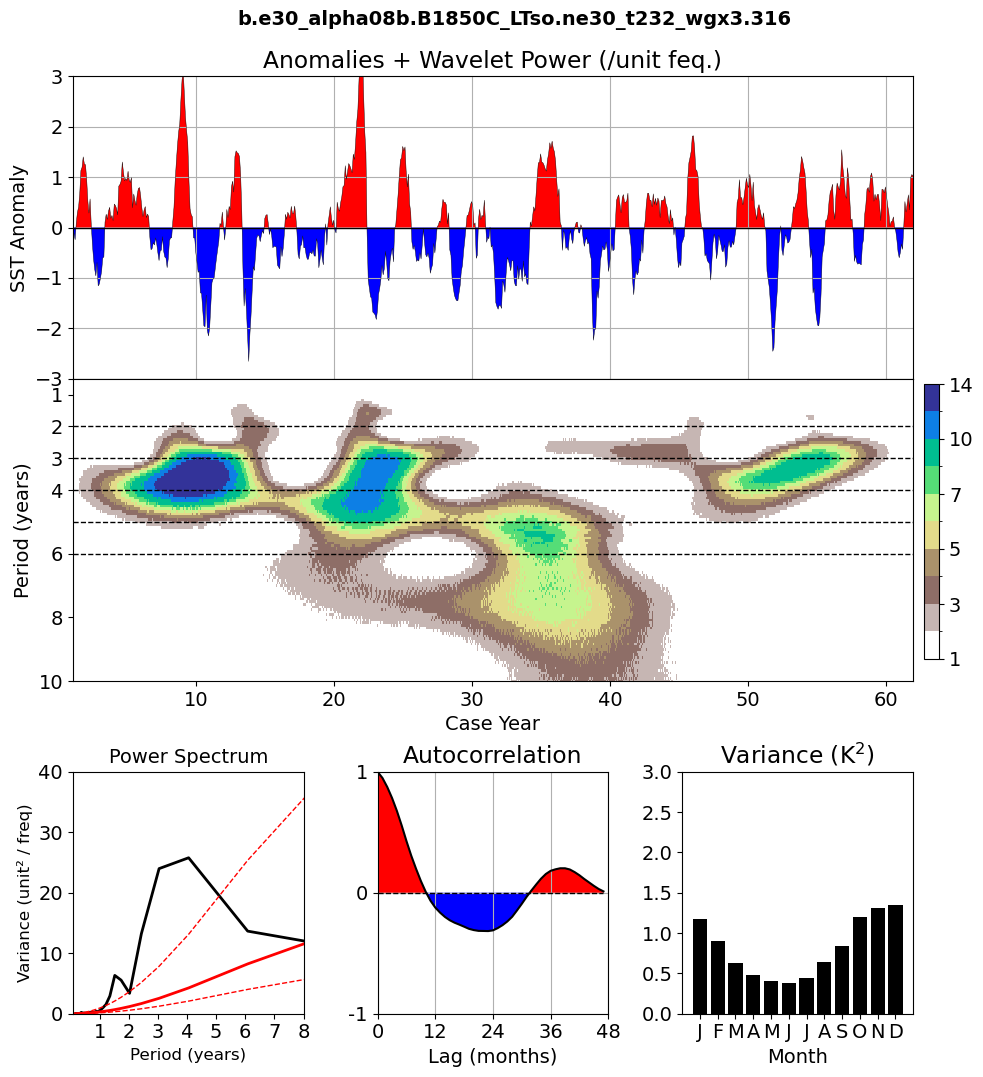

In [7]:
importlib.reload(enso_ql)
dir_fig = '/glade/u/home/rneale/python/python-figs/enso/'

# Simulated Niño3.4 data if you don't have it
#np.random.seed(0)
#n_months = 12 * 50  # 50 years of monthly data
#nino34 = np.random.normal(0, 1, n_months) + np.sin(np.linspace(0, 30 * 2*np.pi, n_months))

# 1. Grab data for x-axis and y-axis variable (obs. or model)

print('')
print('** 1. Grabbing Case Data **')

# Some manipulation because of obs. could be different types ('cases').

var_in = 'TS'
case_owner = 'hannay'

#run_name = 'ERA5' ; run_type = 'OBS' ; year_start = 1950 ; year_stop = 2021
#run_name = 'HADISST' ; run_type = 'OBS' ; year_start = 1940 ; year_stop = 2021





#run_name = 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 135
#run_name = 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.158'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 68
#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.187';run_type = 'cesm3' ; year_start = 1 ; year_stop = 77
#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.181'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 44
#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.188'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 100
#run_name = 'b.e30_alpha07b_dev.B1850C_LTso.ne30_t232_wgx3.198'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 90
#run_name = 'b.e30_alpha07b_dev.B1850C_LTso.ne30_t232_wgx3.213'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 88
#run_name = 'b.e30_alpha07c_cesm.B1850C_LTso.ne30_t232_wgx3.240'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 72
#run_name = 'b.e30_alpha07c_cesm.B1850C_LTso.ne30_t232_wgx3.234'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 80
#run_name = 'b.e30_alpha07c_cesm.B1850C_LTso.ne30_t232_wgx3.247'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 80
#run_name = 'b.e30_alpha07c_cesm.B1850C_LTso.ne30_t232_wgx3.253'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 28

#run_name = 'b.e30_alpha07g.B1850C_LTso.ne30_t232_wgx3.276'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 68
run_name = 'b.e30_alpha08b.B1850C_LTso.ne30_t232_wgx3.316'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 61

#run_name = 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.160'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 100
#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.180'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 44

#run_name = 'b.e11.B1850C5CN.f09_g16.005'; run_type = 'cesm1' ; year_start = 401 ; year_stop = 499
#run_name = 'CESM2_piControl'; run_type = 'cmip6' ; year_start = 401 ; year_stop = 480 # This is the CMIP6 PI control used to initialize the LENS2.

#run_name = '20180129.DECKv1b_piControl.FV1_oEC.edison' ; run_type = 'e3smv1' ; year_start = 401 ; year_stop = 499
#run_name = 'v2.FV1.piControl' ; run_type = 'e3smv2' ; year_start = 401 ; year_stop = 499
#run_name = 'v3.LR.piControl'  ; run_type = 'e3smv3' ; year_start = 401 ; year_stop = 499

ax_frac = 1.

lread_in_all_hist = True # Only read a subet of output data, else read all available data in.
lwrite_ts_file = True
lread_ts_file = True

da_sst = enso_ql.get_dataset(run_name,run_type,case_owner,var_in,year_start,year_stop,lread_in_all_hist,lwrite_ts_file,lread_ts_file)




#print(da_sst['time'])
#da_sst['time'] = pd.to_datetime(da_sst.indexes['time'].to_datetimeindex())
#print(da_sst['time'])



''' Set Time Information (a pain) '''



nino_reg = 'nino34'
nino_ts = enso_ql.nino_anom_ts(da_sst,nino_reg)
time = da_sst.time

# Time axis for plotting (tricky otehrwise with noleap objects)
year_float = da_sst.time.dt.year + (da_sst.time.dt.dayofyear - 1) / 365


ntime = len(time)




print(year_start,year_stop)








''' SETUP GRAPHICS '''
# Setup portrait layout: top 1/3, middle 1/3, bottom split in 3
fig = plt.figure(figsize=(10.5, 11))  # US letter portrait
plt.rcParams.update({'font.size': 14})  # sets font size globally

gs = gridspec.GridSpec(nrows=4, ncols=3, height_ratios=[1, 1, 0.3, 0.8],hspace=0.3)


# Top 2 rows — full width (colspan=3)
ax1 = fig.add_subplot(gs[0, :])  # Top row
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)  # Second row, shared x-axis

gs.update(hspace=0.0)

ax3 = fig.add_subplot(gs[3, 0])
ax4 = fig.add_subplot(gs[3, 1])
ax5 = fig.add_subplot(gs[3, 2])


xl, xr = enso_ql.set_fractional_xlim([ax1, ax2], year_float, frac=ax_frac, anchor="left")



plt.suptitle(run_name, fontweight='bold', fontsize=14)




''' PLOT TIME SERIES '''


# Plot 1: Time series
ax1.plot(year_float, nino_ts, color='black', linewidth=0.3)

ax1.set_title("Anomalies + Wavelet Power (/unit feq.)")
ax1.set_ylabel("SST Anomaly")
ax1.grid(True)
ax1.fill_between(year_float,nino_ts,0, where=nino_ts > 0.,  facecolor='red', interpolate=True)
ax1.fill_between(year_float,nino_ts,0, where=nino_ts < 0.,  facecolor='blue', interpolate=True)

ax1.set_ylim([-3.,3.])
ax1.tick_params(labelbottom=False, bottom=False)



# Then lock the x-limits to desired fraction
D = np.max(year_float) - np.min(year_float)
frac = ax_frac
xmin = np.min(year_float)
xr = xmin + D / frac
ax1.set_xlim(xmin, xr)
ax1.margins(x=0)  # ensures no extra padding

xl, xr = ax1.get_xlim()
ax1.hlines(0., xl,xr, color='black',linestyle="dashed",lw=1,ls='-')




''' PLOT WAVELET '''

# Plot 2: Wavelet spectrum
wavelet = 'cmor1.5-1.0'  # Complex Morlet
scales = np.arange(1, 512)
coeffs, freqs = pywt.cwt(nino_ts, scales, wavelet, sampling_period=1)
#freqs = pd.timeseries(freqs)

periods = 1./(12.*freqs)
power = np.abs(coeffs)**2

levels = [1,2,3,4,5,6,7,8,10,12,14]

cmap = plt.get_cmap('terrain_r', len(levels)-1)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)


p2 = ax2.pcolormesh(year_float, periods, power, shading='nearest', cmap=cmap,norm=norm)

for ii in [2,3,4,5,6]:
    ax2.hlines(ii, xl,xr,colors='black',linestyles='--',lw=1)




ax2.set_ylabel("Period (years)")
ax2.set_xlabel("Case Year")
ax2.set_ylim(0.5, 10)
yperiods = [1,2,3,4,6,8,10]

ax2.set_yticks(yperiods)
ax2.set_yticklabels(yperiods)
ax2.invert_yaxis()



#xticks = np.arange(0, ntime, 12)
#ax2.set_xticks(xticks)
#ax2.set_xticklabels([time[i].strftime('%Y-%m') for i in xticks], rotation=45)

#divider = make_axes_locatable(ax2)
#cax = divider.append_axes("right", size="3%", pad=-0.02)

# Add colorbar there
#cb = fig.colorbar(ax2, cax=cax, orientation='vertical', label='Power')
#fig.colorbar(p, ax=ax2, orientation='vertical', label='Power')
#ax2 = fig.add_axes([0.05, 0.1, 0.95, 0.8])
#ax2.xaxis_date()
#ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
#fig.autofmt_xdate()





''' PLOT FOURIER SPECTRUM '''

# Plot 3: Fourier Spectrum
#N = len(nino_ts)
#yf = fft(nino_ts - np.mean(nino_ts))
#xf = fftfreq(N, d=1)[:N//2]

#power = 2.0 / N * np.abs(yf[1:N//2])
#power = power.rolling(window=10, center=True).mean()
#periods = 1 / (12.*xf)  # now safe, xf[0] excluded


enso_ql.calc_power(ax3,nino_ts)

#ax3.plot(periods, 2.0/N * np.abs(yf[:N//2]), color='black')
#ax3.set_title("Power Spectrum")
#ax3.set_xlabel("Period (years)")
#ax3.set_ylabel("Variance (K$^2$/unit freq.)")
#ax3.set_xlim([0.,8])
#ax3.set_ylim([0.,0.5])

#xp = [1,2,3,4,5,6,7,8]
#ax3.set_xticks(xp)
#ax3.set_xticklabels(xp)












'''PLOT AUTOCORRELATION '''

# Plot 4: Autocorrelation
m_acorr = 48
lags = np.arange(0, m_acorr)
corr = correlate(nino_ts - np.mean(nino_ts), nino_ts - np.mean(nino_ts), mode='full')
corr = corr[corr.size // 2  : corr.size // 2 + m_acorr]
corr /= np.max(corr)
ax4.plot(lags, corr, color='black')
ax4.set_title("Autocorrelation")
ax4.set_ylim([-1.,1.])
ax4.set_xlabel("Lag (months)")

ax4.grid(True)
ax4.hlines(0., min(lags), max(lags), color='black',linestyle="dashed",lw=1)
ax4.fill_between(lags,corr,0, where=corr > 0.,  facecolor='red', interpolate=True)
ax4.fill_between(lags,corr,0, where=corr < 0.,  facecolor='blue', interpolate=True)

xmonths = [0,12,24,36,48]
amonths = [-1,0,1]
ax4.set_yticks(amonths)
ax4.set_yticklabels(amonths)

ax4.set_xticks(xmonths)
ax4.set_xticklabels(xmonths)
ax4.set_xlim([0,48])









''' PLOT MONTHLY MEAN VARIANCES '''



# Plot 5: Monthly Mean Magnitudes

monthly_means = nino_ts.groupby('month').var()
ax5.bar(range(1, 13), monthly_means, color='black')
ax5.set_ylim([0,3.])
ax5.set_title("Variance (K$^2$)")
ax5.set_xlabel("Month")

ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J',
                     'J', 'A', 'S', 'O', 'N', 'D'])

plt.tight_layout()



''' Final Settings '''


# Add shared colorbar for top two plots
cbar_ax = fig.add_axes([0.89, 0.39, 0.015, 0.25])  # [left, bottom, width, height]
fig.colorbar(p2, cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on the right for colorbar"


fig.savefig(dir_fig+run_name+'_'+var_in+'_'+str(year_start)+'-'+str(year_stop)+'_quick_look.png')
plt.show()